In [1]:
# Imports 
import os 
import sys
import random
import numpy as np 
import pandas as pd 
import seisbench.data as sbd
import matplotlib.pyplot as plt
# from pandasgui import show 

pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None) 
pd.set_option('display.max_colwidth', None)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


/home/skevofilaxc/miniconda3/envs/conveqcct/lib/python3.10/site-packages/seisbench/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Get TXED
txed_datasource = sbd.TXED

In [50]:
txed = txed_datasource(sampling_rate=100, component_order='ZNE', cache=None, metadata_cache=False)

In [56]:
example_metadata = txed.metadata[txed.metadata['trace_name'].str.contains('bucket228$70,:3,:6000', na=False, regex=False)]
example_metadata

,index,trace_coda_end_sample,source_depth_km,source_latitude_deg,source_longitude_deg,source_magnitude,source_origin_time,trace_p_arrival_sample,trace_p_arrival_time,trace_p_arrival_uncertainty_s,trace_s_arrival_sample,trace_s_arrival_time,trace_s_arrival_uncertainty_s,trace_snr_db,station_elevation_m,station_latitude_deg,station_longitude_deg,station_code,trace_category,trace_name_original,split,trace_name,trace_causal,trace_polarity,trace_chunk,trace_sampling_rate_hz,trace_component_order
234081,234081,4374.0,4.177759,31.182483,-103.458806,1.292444,2018-04-03T00:30:18.755335Z,938.0,2018-04-03T00:30:42.238319Z,NaN,2656.0,2018-04-03T00:30:59.417724Z,NaN,[-5.47779259 -1.00227134 -0.66316092],943.0,32.12009,-102.54913,ODSA,earthquake_local,texnet2018gmdh_ODSA_EV,train,"bucket228$70,:3,:6000",unknown,unknown,,100,ZNE


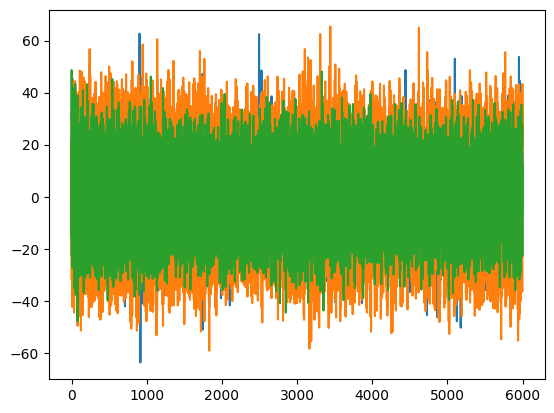

In [57]:
index = example_metadata.index[0]
waveforms = txed.get_waveforms(index)
plt.plot(waveforms.T);

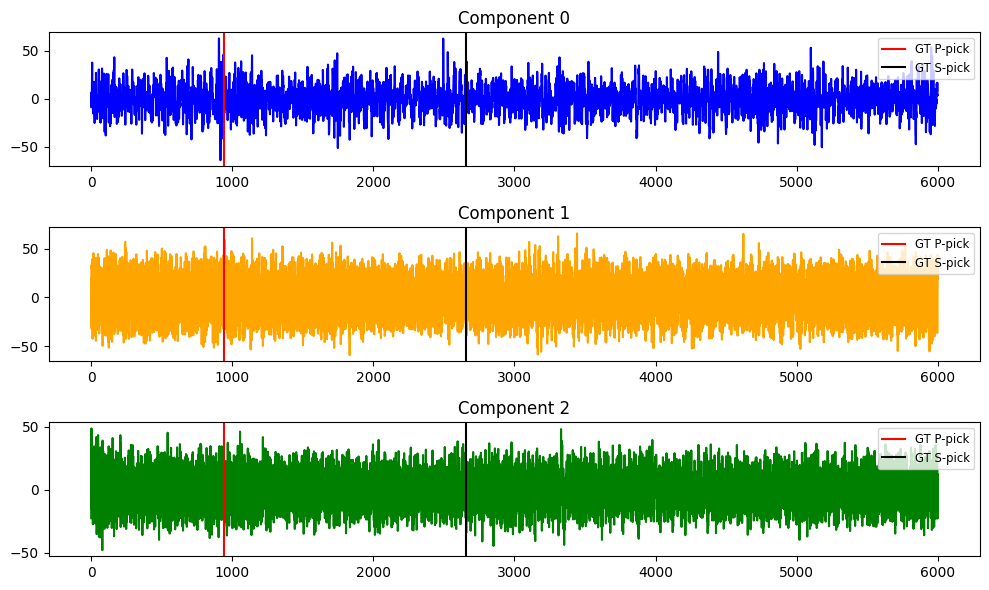

In [58]:
traces, labels = txed.get_sample(index)
colors = ['blue', 'orange', 'green']
num_components = waveforms.shape[0]
fig, axes = plt.subplots(num_components, 1, figsize=(10, 2*num_components))

for i in range(num_components):
    axes[i].plot(traces[i], color=colors[i])
    axes[i].axvline(labels['trace_p_arrival_sample'], color='red', linestyle='-', label='GT P-pick')
    axes[i].axvline(labels['trace_s_arrival_sample'], color='black', linestyle='-', label='GT S-pick')
    axes[i].set_title(f'Component {i}')
    axes[i].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()
